# **Scenario Engine — Curve Impact**

This notebook shows **curve-level impact only** (zero rates, discount factors, forwards,
2s10s slope, and curvature) of applying parametric, wing-anchored twist, and butterfly
shocks to the real BoE-bootstrapped SONIA curve.

## **Scope and known limitations**

**Scope**: this notebook shows curve-level impact only — zero rates, discount
factors, forward rates, 2s10s slope, and curvature under each scenario.
Swap valuation, DV01/key-rate duration, and P&L attribution are explicitly
**out of scope** here and are covered by Project 2 (Rates Portfolio P&L
Attribution Engine), which builds on this curve rather than duplicating it.

**Known limitation — QuantLib cross-validation residual**: independent
validation of this project's bootstrap against QuantLib showed a small
residual (~1–2bp) across most pillars (see `README.md` for the full
comparison table). Two candidate explanations were tested and ruled out:
the interpolation method (log-linear vs log-cubic only affects values
*between* pillars, never *at* them, by construction) and QuantLib's UK
business-day calendar (removing it via `ql.NullCalendar()` did not close
the gap). The leading remaining candidate is that this project's naive
`τ = 1.0` per annual period differs from QuantLib's actual calendar-date
Act/365 fraction whenever a period spans a leap day (`τ ≈ 1.0027`) — this
would explain both the small magnitude and the non-monotonic, alternating
sign pattern across tenors. Not yet directly isolated with a dedicated
`τ`-comparison test; parked as a refinement item alongside full business-day
convention support (see `CLAUDE.md`).

In [1]:
import csv
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from src.bootstrap import bootstrap_curve
from src.curve import Curve
from src.scenarios import (
    apply_butterfly_shock,
    apply_parametric_shock,
    apply_wing_anchored_twist,
)

%matplotlib inline

In [2]:
quotes = []
with open(REPO_ROOT / "data/processed/boe_ois_quotes.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        quotes.append((float(row["tenor_years"]), float(row["rate"])))

dfs = bootstrap_curve(quotes)
curve = Curve(dfs)
tenors = [T for T, _ in curve.pillars]
tenors

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

## Metrics

In [3]:
def slope_2s10s(curve):
    return curve.zero_rate(10.0) - curve.zero_rate(2.0)


def curvature(curve):
    return 2 * curve.zero_rate(5.0) - curve.zero_rate(2.0) - curve.zero_rate(10.0)

## Chart styling

Fixed categorical colors (validated for CVD-safe contrast — see the project's
dataviz palette): **blue = base curve**, **red = shocked curve**, used consistently
across every scenario so color identity never shifts from chart to chart.

In [4]:
COLOR_BASE = "#2a78d6"
COLOR_SHOCKED = "#e34948"
COLOR_PRIMARY = "#0b0b0b"
COLOR_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("blue_gray_red", [COLOR_BASE, "#f0efec", COLOR_SHOCKED])


def _style_axes(ax):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(COLOR_BASELINE)
    ax.tick_params(colors=COLOR_SECONDARY, labelsize=9)
    ax.yaxis.grid(True, color=COLOR_GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)


def _style_delta_table(df: pd.DataFrame):
    """Format rate columns as %, bp columns as signed integers, discount
    factors/tenors to fixed precision, and apply a diverging (blue-gray-red)
    background to each bp column, centered on zero.

    NOTE: build the format dict for every column and call .style.format() once --
    chaining .format(a).format(b) silently drops the first call's formatters
    in this pandas version (confirmed in isolation), it does not merge them.
    """
    delta_cols = [c for c in df.columns if "(bp)" in c]
    rate_cols = [c for c in df.columns if c not in delta_cols and ("z(" in c or "fwd" in c.lower())]
    df_cols = [c for c in df.columns if c in ("Base D(T)", "Shocked D(T)")]
    tenor_cols = [c for c in df.columns if c in ("Tenor", "T1", "T2")]

    fmt = {}
    fmt.update({c: "{:.4%}" for c in rate_cols})
    fmt.update({c: "{:+.1f}" for c in delta_cols})
    fmt.update({c: "{:.6f}" for c in df_cols})
    fmt.update({c: "{:.0f}" for c in tenor_cols})

    styler = df.style.format(fmt)
    for c in delta_cols:
        vmax = max(1.0, df[c].abs().max())
        styler = styler.background_gradient(cmap=DIVERGING_CMAP, subset=[c], vmin=-vmax, vmax=vmax)
    return styler.hide(axis="index")

## `run_scenario` — the reusable simulation entry point

Call this directly with **any** shock parameters you want to explore — it isn't
tied to the 10 scenarios below. `shock_fn` is any `Curve -> Curve` callable, so you
can pass `apply_parametric_shock`, `apply_wing_anchored_twist`, `apply_butterfly_shock`,
or your own lambda, with whatever parameter values you choose. The optional
`pivot_tenor` / `wing_short` / `wing_long` / `belly` arguments only control which
reference lines get drawn on the chart — they don't affect the shock itself.

In [5]:
def run_scenario(
    curve: Curve,
    name: str,
    shock_fn,
    qualitative_text: str | None = None,
    *,
    shock_label: str | None = None,
    pivot_tenor: float | None = None,
    wing_short: float | None = None,
    wing_long: float | None = None,
    belly: float | None = None,
    show_tables: bool = True,
    show_plot: bool = True,
) -> dict:
    """Apply shock_fn to curve and report tenor-by-tenor + summary impact.

    Example — simulate your own parameters directly:
        run_scenario(
            curve, "My custom twist",
            lambda c: apply_parametric_shock(c, level_shift=0.004, slope_shift=-0.0015, pivot_tenor=4.0),
            shock_label="level +40bp, slope -15bp, pivot 4Y",
            pivot_tenor=4.0,
        )
    """
    shocked = shock_fn(curve)
    tenors = [T for T, _ in curve.pillars]

    impact_df = pd.DataFrame([
        {
            "Tenor": T,
            "Base z(T)": curve.zero_rate(T),
            "Shocked z(T)": shocked.zero_rate(T),
            "\u0394z (bp)": (shocked.zero_rate(T) - curve.zero_rate(T)) * 10000,
            "Base D(T)": curve.discount_factor(T),
            "Shocked D(T)": shocked.discount_factor(T),
        }
        for T in tenors
    ])
    fwd_df = pd.DataFrame([
        {
            "T1": T1,
            "T2": T2,
            "Base fwd": curve.forward_rate(T1, T2),
            "Shocked fwd": shocked.forward_rate(T1, T2),
            "\u0394fwd (bp)": (shocked.forward_rate(T1, T2) - curve.forward_rate(T1, T2)) * 10000,
        }
        for T1, T2 in zip(tenors[:-1], tenors[1:])
    ])

    if show_tables:
        print(f"{'=' * 100}\n{name}\n{'=' * 100}")
        display(_style_delta_table(impact_df))
        display(_style_delta_table(fwd_df))

    if show_plot:
        base_z = [curve.zero_rate(T) * 100 for T in tenors]
        shocked_z = [shocked.zero_rate(T) * 100 for T in tenors]

        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.plot(
            tenors, base_z, color=COLOR_BASE, linewidth=2, marker="o", markersize=8,
            markerfacecolor=COLOR_BASE, markeredgecolor="white", markeredgewidth=1.5,
            label="Base", zorder=3,
        )
        ax.plot(
            tenors, shocked_z, color=COLOR_SHOCKED, linewidth=2, marker="o", markersize=8,
            markerfacecolor=COLOR_SHOCKED, markeredgecolor="white", markeredgewidth=1.5,
            label="Shocked", zorder=3,
        )

        anchors = []
        if pivot_tenor is not None:
            anchors.append((pivot_tenor, "pivot"))
        if wing_short is not None:
            anchors.append((wing_short, "wing"))
        if wing_long is not None:
            anchors.append((wing_long, "wing"))
        if belly is not None:
            anchors.append((belly, "belly"))
        for x, label in anchors:
            ax.axvline(x, color=COLOR_BASELINE, linewidth=1, linestyle="--", zorder=1)
            ax.text(
                x, 0.97, f"{label} {x:g}Y", transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=8, color=COLOR_MUTED,
                bbox=dict(facecolor="#fcfcfb", edgecolor="none", pad=1.5),
            )

        last_T = tenors[-1]
        ax.set_xlim(tenors[0] - 0.4, tenors[-1] + 1.3)
        ax.annotate(
            f"{base_z[-1]:.2f}%", xy=(last_T, base_z[-1]), xytext=(8, 0), textcoords="offset points",
            va="center", fontsize=9, color=COLOR_SECONDARY,
        )
        ax.annotate(
            f"{shocked_z[-1]:.2f}%", xy=(last_T, shocked_z[-1]), xytext=(8, 0), textcoords="offset points",
            va="center", fontsize=9, color=COLOR_SECONDARY,
        )

        for T in (2.0, 5.0, 10.0):
            if T in tenors:
                delta_bp = (shocked.zero_rate(T) - curve.zero_rate(T)) * 10000
                y = shocked.zero_rate(T) * 100
                ax.annotate(
                    f"{delta_bp:+.0f}bp", xy=(T, y),
                    xytext=(0, 11 if delta_bp >= 0 else -15), textcoords="offset points",
                    ha="center", fontsize=8, color=COLOR_SECONDARY,
                )

        ax.set_xlabel("Tenor (years)", color=COLOR_SECONDARY, fontsize=10)
        ax.set_ylabel("Zero rate (%)", color=COLOR_SECONDARY, fontsize=10)
        ax.set_xticks(tenors)
        _style_axes(ax)

        fig.suptitle(name, x=0.09, y=1.03, ha="left", fontsize=13, fontweight="bold", color=COLOR_PRIMARY)
        if shock_label:
            ax.set_title(shock_label, fontsize=9.5, color=COLOR_SECONDARY, loc="left", pad=10)

        ax.legend(loc="best", frameon=False, fontsize=9, labelcolor=COLOR_SECONDARY)

        ymin, ymax = ax.get_ylim()
        pad = (ymax - ymin) * 0.15
        ax.set_ylim(ymin - pad * 0.3, ymax + pad)

        plt.show()

    if qualitative_text:
        print(qualitative_text)
        print()

    return {
        "Scenario": name,
        "\u0394z(2Y) (bp)": (shocked.zero_rate(2.0) - curve.zero_rate(2.0)) * 10000,
        "\u0394z(5Y) (bp)": (shocked.zero_rate(5.0) - curve.zero_rate(5.0)) * 10000,
        "\u0394z(10Y) (bp)": (shocked.zero_rate(10.0) - curve.zero_rate(10.0)) * 10000,
        "\u0394(2s10s) (bp)": (slope_2s10s(shocked) - slope_2s10s(curve)) * 10000,
        "\u0394curvature (bp)": (curvature(shocked) - curvature(curve)) * 10000,
    }

## Scenario definitions

In [6]:
scenarios = [
    dict(
        name="+25bp parallel shift",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=0.0025, slope_shift=0.0, pivot_tenor=5.0),
        shock_label="level +25bp",
    ),
    dict(
        name="-25bp parallel shift",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=-0.0025, slope_shift=0.0, pivot_tenor=5.0),
        shock_label="level -25bp",
    ),
    dict(
        name="+100bp stress shock",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=0.01, slope_shift=0.0, pivot_tenor=5.0),
        shock_label="level +100bp",
    ),
    dict(
        name="Bear flattener",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=0.005, slope_shift=-0.003, pivot_tenor=5.0),
        shock_label="level +50bp, slope -30bp, pivot 5Y",
        pivot_tenor=5.0,
    ),
    dict(
        name="Bear steepener",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=0.005, slope_shift=0.003, pivot_tenor=5.0),
        shock_label="level +50bp, slope +30bp, pivot 5Y",
        pivot_tenor=5.0,
    ),
    dict(
        name="Bull flattener",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=-0.005, slope_shift=-0.003, pivot_tenor=5.0),
        shock_label="level -50bp, slope -30bp, pivot 5Y",
        pivot_tenor=5.0,
    ),
    dict(
        name="Bull steepener",
        shock_fn=lambda c: apply_parametric_shock(c, level_shift=-0.005, slope_shift=0.003, pivot_tenor=5.0),
        shock_label="level -50bp, slope +30bp, pivot 5Y",
        pivot_tenor=5.0,
    ),
    dict(
        name="2s10s steepener",
        shock_fn=lambda c: apply_wing_anchored_twist(c, wing_short=2.0, wing_long=10.0, shock_short=-0.0025, shock_long=0.0025),
        shock_label="short -25bp, long +25bp",
        wing_short=2.0, wing_long=10.0,
    ),
    dict(
        name="2s10s flattener",
        shock_fn=lambda c: apply_wing_anchored_twist(c, wing_short=2.0, wing_long=10.0, shock_short=0.0025, shock_long=-0.0025),
        shock_label="short +25bp, long -25bp",
        wing_short=2.0, wing_long=10.0,
    ),
    dict(
        name="Butterfly/curvature",
        shock_fn=lambda c: apply_butterfly_shock(c, wing_short=2.0, belly=5.0, wing_long=10.0, wing_shock=-0.0025, belly_shock=0.0025),
        shock_label="wing -25bp, belly +25bp",
        wing_short=2.0, belly=5.0, wing_long=10.0,
    ),
]

In [7]:
qualitative = {
    "+25bp parallel shift": "Broad-based rate increase across all tenors — hawkish repricing of the entire policy path (front end) alongside proportionally higher long-run growth/inflation expectations (long end). Curve shape unchanged.",
    "-25bp parallel shift": "Broad-based rate decrease — dovish repricing of near-term BoE policy (front end) alongside lower long-run growth/inflation expectations (long end), curve shape preserved.",
    "+100bp stress shock": "Severe uniform stress across the curve, consistent with a shock inflation print or a sudden repricing of the terminal rate. A stress-test magnitude, not a base-case move.",
    "Bear flattener": "Front end rises faster than the long end — classic hiking-cycle signature: BoE tightening near-term policy (2Y) while the long end (10Y) rises less, as tighter policy today is expected to cap growth/inflation later.",
    "Bear steepener": "Long end rises faster than the front end — rising term premium or inflation/fiscal-risk concerns pricing further out, while near-term policy (front end) stays comparatively anchored.",
    "Bull flattener": "Long end falls faster than the front end — flight-to-quality/recession-fear signature: long-run growth/inflation expectations drop sharply while near-term policy (anchored to the next few MPC meetings) is slower to reprice.",
    "Bull steepener": "Front end falls faster than the long end — the market pricing imminent BoE rate cuts (front end drops on dovish repricing) while long-run growth/inflation expectations hold up better.",
    "2s10s steepener": "2s10s spread widens — near-term cut expectations (2Y, anchored to the next few MPC decisions) against firmer long-run growth/inflation expectations (10Y), or fiscal/term-premium pressure pushing the long end up in isolation.",
    "2s10s flattener": "2s10s spread narrows — hiking-cycle or growth-scare signature: near-term policy expectations (2Y) stay elevated while long-run growth/inflation expectations (10Y) compress.",
    "Butterfly/curvature": "Belly (5Y) moves opposite to both wings (2Y, 10Y) — a shift in medium-term policy/structural expectations relative to both near-term policy and long-run growth/inflation, often around a change in the expected timing of the policy cycle rather than its direction.",
}

## **Run all 10 scenarios**

+25bp parallel shift


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.0851%,+25.0,0.962375,0.959972
2,3.9077%,4.1577%,+25.0,0.924822,0.920209
3,3.9095%,4.1595%,+25.0,0.889333,0.882688
4,3.9196%,4.1696%,+25.0,0.854890,0.846384
5,3.9526%,4.2026%,+25.0,0.820675,0.810481
6,4.0033%,4.2533%,+25.0,0.786470,0.774761
7,4.0654%,4.3154%,+25.0,0.752333,0.739282
8,4.1340%,4.3840%,+25.0,0.718407,0.704182
9,4.2062%,4.4562%,+25.0,0.684847,0.669610
10,4.2802%,4.5302%,+25.0,0.651801,0.635708


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.2303%,+25.0
2,3,3.9129%,4.1629%,+25.0
3,4,3.9499%,4.1999%,+25.0
4,5,4.0845%,4.3345%,+25.0
5,6,4.2572%,4.5072%,+25.0
6,7,4.4376%,4.6876%,+25.0
7,8,4.6142%,4.8642%,+25.0
8,9,4.7841%,5.0341%,+25.0
9,10,4.9456%,5.1956%,+25.0


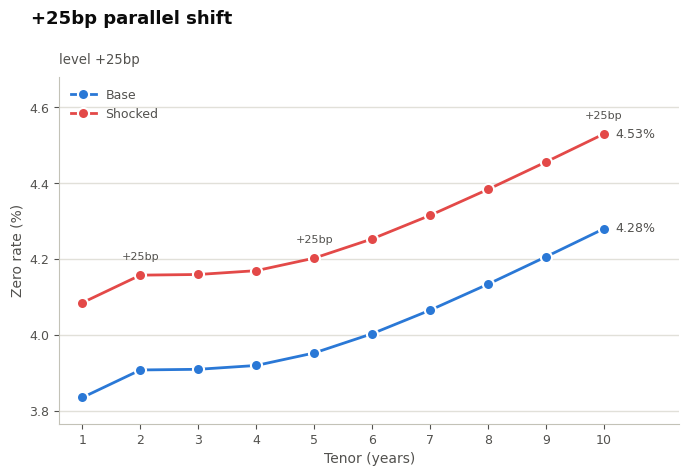

Broad-based rate increase across all tenors — hawkish repricing of the entire policy path (front end) alongside proportionally higher long-run growth/inflation expectations (long end). Curve shape unchanged.

-25bp parallel shift


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,3.5851%,-25.0,0.962375,0.964784
2,3.9077%,3.6577%,-25.0,0.924822,0.929457
3,3.9095%,3.6595%,-25.0,0.889333,0.896028
4,3.9196%,3.6696%,-25.0,0.854890,0.863482
5,3.9526%,3.7026%,-25.0,0.820675,0.830998
6,4.0033%,3.7533%,-25.0,0.786470,0.798356
7,4.0654%,3.8154%,-25.0,0.752333,0.765615
8,4.1340%,3.8840%,-25.0,0.718407,0.732920
9,4.2062%,3.9562%,-25.0,0.684847,0.700431
10,4.2802%,4.0302%,-25.0,0.651801,0.668302


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,3.7303%,-25.0
2,3,3.9129%,3.6629%,-25.0
3,4,3.9499%,3.6999%,-25.0
4,5,4.0845%,3.8345%,-25.0
5,6,4.2572%,4.0072%,-25.0
6,7,4.4376%,4.1876%,-25.0
7,8,4.6142%,4.3642%,-25.0
8,9,4.7841%,4.5341%,-25.0
9,10,4.9456%,4.6956%,-25.0


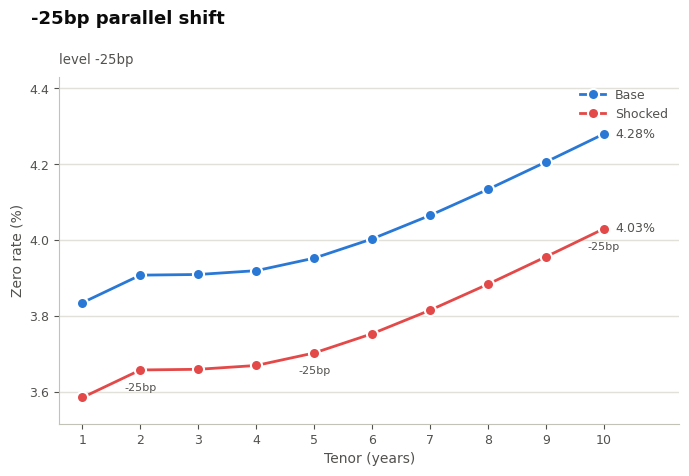

Broad-based rate decrease — dovish repricing of near-term BoE policy (front end) alongside lower long-run growth/inflation expectations (long end), curve shape preserved.

+100bp stress shock


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.8351%,+100.0,0.962375,0.952799
2,3.9077%,4.9077%,+100.0,0.924822,0.906509
3,3.9095%,4.9095%,+100.0,0.889333,0.863049
4,3.9196%,4.9196%,+100.0,0.854890,0.821369
5,3.9526%,4.9526%,+100.0,0.820675,0.780650
6,4.0033%,5.0033%,+100.0,0.786470,0.740670
7,4.0654%,5.0654%,+100.0,0.752333,0.701471
8,4.1340%,5.1340%,+100.0,0.718407,0.663174
9,4.2062%,5.2062%,+100.0,0.684847,0.625903
10,4.2802%,5.2802%,+100.0,0.651801,0.589774


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.9803%,+100.0
2,3,3.9129%,4.9129%,+100.0
3,4,3.9499%,4.9499%,+100.0
4,5,4.0845%,5.0845%,+100.0
5,6,4.2572%,5.2572%,+100.0
6,7,4.4376%,5.4376%,+100.0
7,8,4.6142%,5.6142%,+100.0
8,9,4.7841%,5.7841%,+100.0
9,10,4.9456%,5.9456%,+100.0


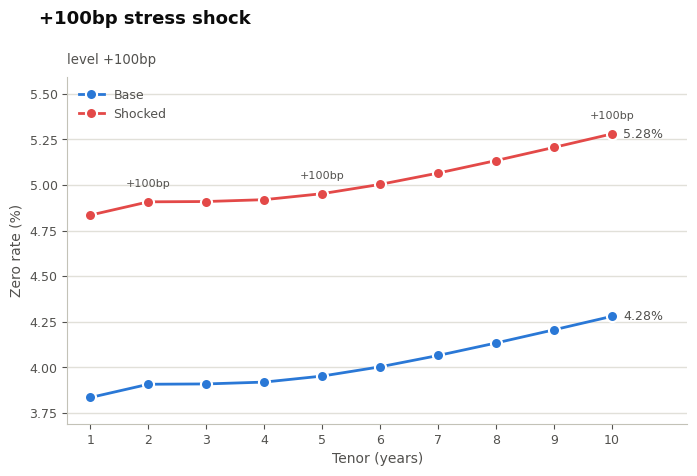

Severe uniform stress across the curve, consistent with a shock inflation print or a sudden repricing of the terminal rate. A stress-test magnitude, not a base-case move.

Bear flattener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.6351%,+80.0,0.962375,0.954707
2,3.9077%,4.6327%,+72.5,0.924822,0.911508
3,3.9095%,4.5595%,+65.0,0.889333,0.872159
4,3.9196%,4.4946%,+57.5,0.854890,0.835452
5,3.9526%,4.4526%,+50.0,0.820675,0.800413
6,4.0033%,4.4433%,+44.0,0.786470,0.765979
7,4.0654%,4.4454%,+38.0,0.752333,0.732585
8,4.1340%,4.4540%,+32.0,0.718407,0.700250
9,4.2062%,4.4662%,+26.0,0.684847,0.669008
10,4.2802%,4.4802%,+20.0,0.651801,0.638895


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.6303%,+65.0
2,3,3.9129%,4.4129%,+50.0
3,4,3.9499%,4.2999%,+35.0
4,5,4.0845%,4.2845%,+20.0
5,6,4.2572%,4.3972%,+14.0
6,7,4.4376%,4.4576%,+2.0
7,8,4.6142%,4.5142%,-10.0
8,9,4.7841%,4.5641%,-22.0
9,10,4.9456%,4.6056%,-34.0


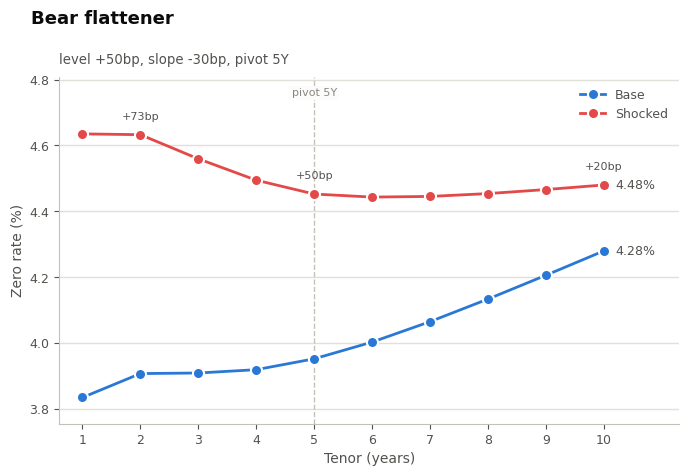

Front end rises faster than the long end — classic hiking-cycle signature: BoE tightening near-term policy (2Y) while the long end (10Y) rises less, as tighter policy today is expected to cap growth/inflation later.

Bear steepener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.0351%,+20.0,0.962375,0.960452
2,3.9077%,4.1827%,+27.5,0.924822,0.919749
3,3.9095%,4.2595%,+35.0,0.889333,0.880044
4,3.9196%,4.3446%,+42.5,0.854890,0.840480
5,3.9526%,4.4526%,+50.0,0.820675,0.800413
6,4.0033%,4.5633%,+56.0,0.786470,0.760484
7,4.0654%,4.6854%,+62.0,0.752333,0.720380
8,4.1340%,4.8140%,+68.0,0.718407,0.680370
9,4.2062%,4.9462%,+74.0,0.684847,0.640722
10,4.2802%,5.0802%,+80.0,0.651801,0.601688


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.3303%,+35.0
2,3,3.9129%,4.4129%,+50.0
3,4,3.9499%,4.5999%,+65.0
4,5,4.0845%,4.8845%,+80.0
5,6,4.2572%,5.1172%,+86.0
6,7,4.4376%,5.4176%,+98.0
7,8,4.6142%,5.7142%,+110.0
8,9,4.7841%,6.0041%,+122.0
9,10,4.9456%,6.2856%,+134.0


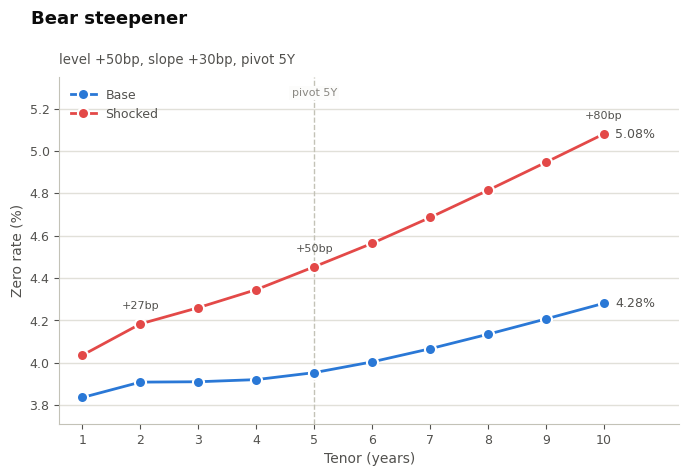

Long end rises faster than the front end — rising term premium or inflation/fiscal-risk concerns pricing further out, while near-term policy (front end) stays comparatively anchored.

Bull flattener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,3.6351%,-20.0,0.962375,0.964302
2,3.9077%,3.6327%,-27.5,0.924822,0.929922
3,3.9095%,3.5595%,-35.0,0.889333,0.898720
4,3.9196%,3.4946%,-42.5,0.854890,0.869547
5,3.9526%,3.4526%,-50.0,0.820675,0.841451
6,4.0033%,3.4433%,-56.0,0.786470,0.813345
7,4.0654%,3.4454%,-62.0,0.752333,0.785703
8,4.1340%,3.4540%,-68.0,0.718407,0.758571
9,4.2062%,3.4662%,-74.0,0.684847,0.732011
10,4.2802%,3.4802%,-80.0,0.651801,0.706088


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,3.6303%,-35.0
2,3,3.9129%,3.4129%,-50.0
3,4,3.9499%,3.2999%,-65.0
4,5,4.0845%,3.2845%,-80.0
5,6,4.2572%,3.3972%,-86.0
6,7,4.4376%,3.4576%,-98.0
7,8,4.6142%,3.5142%,-110.0
8,9,4.7841%,3.5641%,-122.0
9,10,4.9456%,3.6056%,-134.0


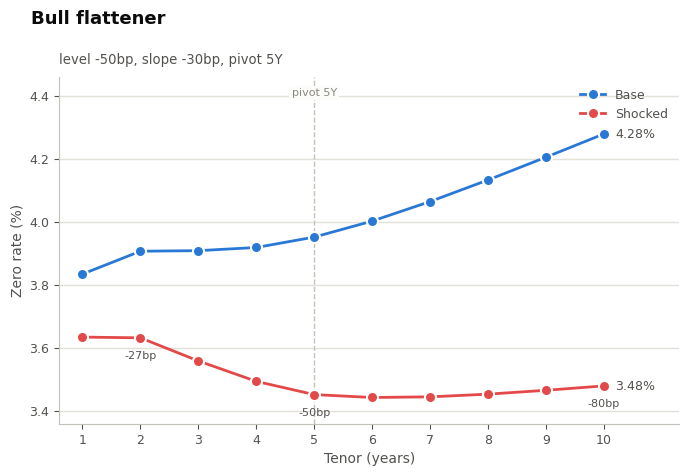

Long end falls faster than the front end — flight-to-quality/recession-fear signature: long-run growth/inflation expectations drop sharply while near-term policy (anchored to the next few MPC meetings) is slower to reprice.

Bull steepener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,3.0351%,-80.0,0.962375,0.970105
2,3.9077%,3.1827%,-72.5,0.924822,0.938329
3,3.9095%,3.2595%,-65.0,0.889333,0.906845
4,3.9196%,3.3446%,-57.5,0.854890,0.874780
5,3.9526%,3.4526%,-50.0,0.820675,0.841451
6,4.0033%,3.5633%,-44.0,0.786470,0.807510
7,4.0654%,3.6854%,-38.0,0.752333,0.772614
8,4.1340%,3.8140%,-32.0,0.718407,0.737036
9,4.2062%,3.9462%,-26.0,0.684847,0.701062
10,4.2802%,4.0802%,-20.0,0.651801,0.664969


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,3.3303%,-65.0
2,3,3.9129%,3.4129%,-50.0
3,4,3.9499%,3.5999%,-35.0
4,5,4.0845%,3.8845%,-20.0
5,6,4.2572%,4.1172%,-14.0
6,7,4.4376%,4.4176%,-2.0
7,8,4.6142%,4.7142%,+10.0
8,9,4.7841%,5.0041%,+22.0
9,10,4.9456%,5.2856%,+34.0


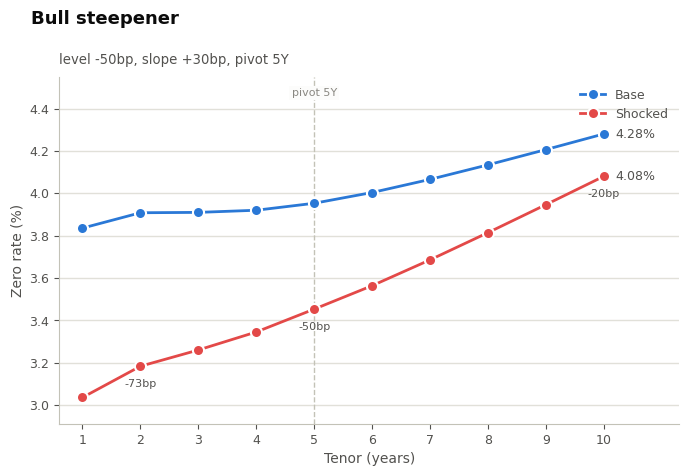

Front end falls faster than the long end — the market pricing imminent BoE rate cuts (front end drops on dovish repricing) while long-run growth/inflation expectations hold up better.

2s10s steepener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,3.5851%,-25.0,0.962375,0.964784
2,3.9077%,3.6577%,-25.0,0.924822,0.929457
3,3.9095%,3.7220%,-18.7,0.889333,0.894349
4,3.9196%,3.7946%,-12.5,0.854890,0.859175
5,3.9526%,3.8901%,-6.3,0.820675,0.823244
6,4.0033%,4.0033%,+0.0,0.786470,0.786470
7,4.0654%,4.1279%,+6.2,0.752333,0.749049
8,4.1340%,4.2590%,+12.5,0.718407,0.711259
9,4.2062%,4.3937%,+18.8,0.684847,0.673387
10,4.2802%,4.5302%,+25.0,0.651801,0.635708


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,3.7303%,-25.0
2,3,3.9129%,3.8504%,-6.2
3,4,3.9499%,4.0124%,+6.2
4,5,4.0845%,4.2720%,+18.8
5,6,4.2572%,4.5697%,+31.3
6,7,4.4376%,4.8751%,+43.7
7,8,4.6142%,5.1767%,+56.3
8,9,4.7841%,5.4716%,+68.7
9,10,4.9456%,5.7581%,+81.3


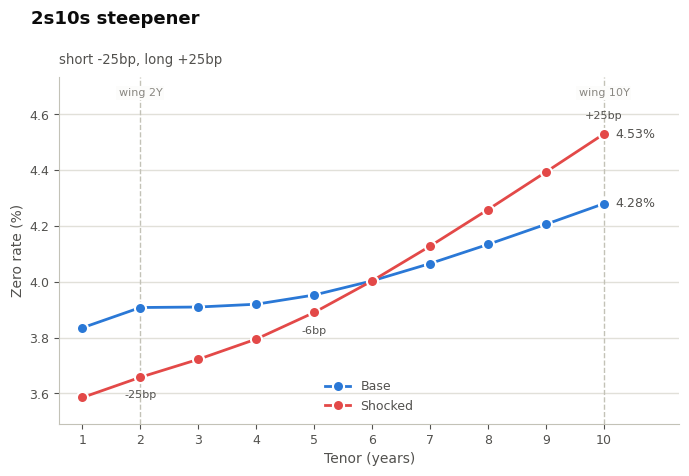

2s10s spread widens — near-term cut expectations (2Y, anchored to the next few MPC decisions) against firmer long-run growth/inflation expectations (10Y), or fiscal/term-premium pressure pushing the long end up in isolation.

2s10s flattener


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.0851%,+25.0,0.962375,0.959972
2,3.9077%,4.1577%,+25.0,0.924822,0.920209
3,3.9095%,4.0970%,+18.7,0.889333,0.884344
4,3.9196%,4.0446%,+12.5,0.854890,0.850626
5,3.9526%,4.0151%,+6.3,0.820675,0.818115
6,4.0033%,4.0033%,+0.0,0.786470,0.786470
7,4.0654%,4.0029%,-6.2,0.752333,0.755632
8,4.1340%,4.0090%,-12.5,0.718407,0.725628
9,4.2062%,4.0187%,-18.8,0.684847,0.696502
10,4.2802%,4.0302%,-25.0,0.651801,0.668302


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.2303%,+25.0
2,3,3.9129%,3.9754%,+6.2
3,4,3.9499%,3.8874%,-6.2
4,5,4.0845%,3.8970%,-18.7
5,6,4.2572%,3.9447%,-31.3
6,7,4.4376%,4.0001%,-43.7
7,8,4.6142%,4.0517%,-56.2
8,9,4.7841%,4.0966%,-68.8
9,10,4.9456%,4.1331%,-81.2


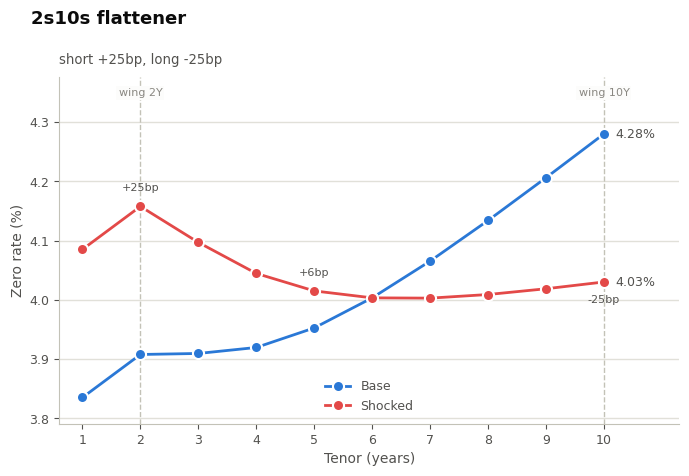

2s10s spread narrows — hiking-cycle or growth-scare signature: near-term policy expectations (2Y) stay elevated while long-run growth/inflation expectations (10Y) compress.

Butterfly/curvature


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,3.5851%,-25.0,0.962375,0.964784
2,3.9077%,3.6577%,-25.0,0.924822,0.929457
3,3.9095%,3.8261%,-8.3,0.889333,0.891559
4,3.9196%,4.0029%,+8.3,0.854890,0.852045
5,3.9526%,4.2026%,+25.0,0.820675,0.810481
6,4.0033%,4.1533%,+15.0,0.786470,0.779424
7,4.0654%,4.1154%,+5.0,0.752333,0.749705
8,4.1340%,4.0840%,-5.0,0.718407,0.721287
9,4.2062%,4.0562%,-15.0,0.684847,0.694155
10,4.2802%,4.0302%,-25.0,0.651801,0.668302


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,3.7303%,-25.0
2,3,3.9129%,4.1629%,+25.0
3,4,3.9499%,4.5332%,+58.3
4,5,4.0845%,5.0012%,+91.7
5,6,4.2572%,3.9072%,-35.0
6,7,4.4376%,3.8876%,-55.0
7,8,4.6142%,3.8642%,-75.0
8,9,4.7841%,3.8341%,-95.0
9,10,4.9456%,3.7956%,-115.0


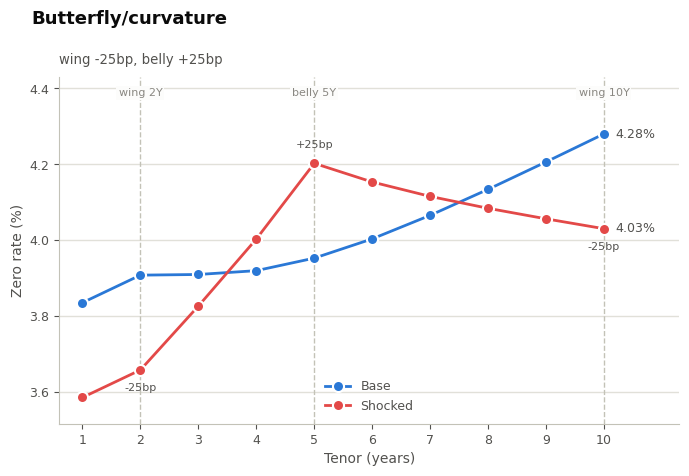

Belly (5Y) moves opposite to both wings (2Y, 10Y) — a shift in medium-term policy/structural expectations relative to both near-term policy and long-run growth/inflation, often around a change in the expected timing of the policy cycle rather than its direction.



In [8]:
summary_rows = []

for spec in scenarios:
    row = run_scenario(curve, **spec, qualitative_text=qualitative[spec["name"]])
    summary_rows.append(row)

## Try your own scenario

`run_scenario` isn't limited to the 10 cases above — call it with any parameters
you want to explore. For example, a +40bp level shift with a -15bp flattening
twist pivoted at 4Y instead of 5Y:

Custom: +40bp level, -15bp twist, 4Y pivot


Tenor,Base z(T),Shocked z(T),Δz (bp),Base D(T),Shocked D(T)
1,3.8351%,4.3851%,+55.0,0.962375,0.957096
2,3.9077%,4.4077%,+50.0,0.924822,0.915619
3,3.9095%,4.3595%,+45.0,0.889333,0.877407
4,3.9196%,4.3196%,+40.0,0.854890,0.841320
5,3.9526%,4.3276%,+37.5,0.820675,0.805431
6,4.0033%,4.3533%,+35.0,0.786470,0.770127
7,4.0654%,4.3904%,+32.5,0.752333,0.735411
8,4.1340%,4.4340%,+30.0,0.718407,0.701371
9,4.2062%,4.4812%,+27.5,0.684847,0.668105
10,4.2802%,4.5302%,+25.0,0.651801,0.635708


T1,T2,Base fwd,Shocked fwd,Δfwd (bp)
1,2,3.9803%,4.4303%,+45.0
2,3,3.9129%,4.2629%,+35.0
3,4,3.9499%,4.1999%,+25.0
4,5,4.0845%,4.3595%,+27.5
5,6,4.2572%,4.4822%,+22.5
6,7,4.4376%,4.6126%,+17.5
7,8,4.6142%,4.7392%,+12.5
8,9,4.7841%,4.8591%,+7.5
9,10,4.9456%,4.9706%,+2.5


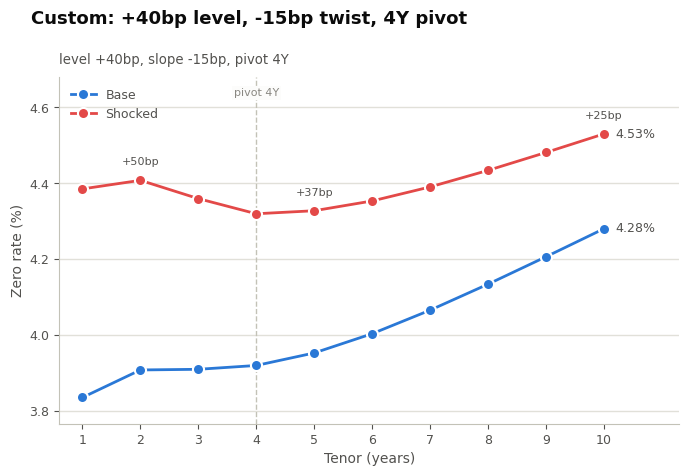

{'Scenario': 'Custom: +40bp level, -15bp twist, 4Y pivot',
 'Δz(2Y) (bp)': 49.99999999999991,
 'Δz(5Y) (bp)': 37.49999999999989,
 'Δz(10Y) (bp)': 25.00000000000002,
 'Δ(2s10s) (bp)': -24.999999999999883,
 'Δcurvature (bp)': -1.3877787807814457e-13}

In [9]:
custom_row = run_scenario(
    curve,
    "Custom: +40bp level, -15bp twist, 4Y pivot",
    lambda c: apply_parametric_shock(c, level_shift=0.004, slope_shift=-0.0015, pivot_tenor=4.0),
    shock_label="level +40bp, slope -15bp, pivot 4Y",
    pivot_tenor=4.0,
)
custom_row

## **Summary: rate impact across all 10 scenarios**

In [10]:
summary_df = pd.DataFrame(summary_rows)
bp_cols = [c for c in summary_df.columns if c != "Scenario"]
vmax = summary_df[bp_cols].abs().max().max()

summary_df.style.format({c: "{:+.1f}" for c in bp_cols}).background_gradient(
    cmap=DIVERGING_CMAP, subset=bp_cols, vmin=-vmax, vmax=vmax
).hide(axis="index")

Scenario,Δz(2Y) (bp),Δz(5Y) (bp),Δz(10Y) (bp),Δ(2s10s) (bp),Δcurvature (bp)
+25bp parallel shift,+25.0,+25.0,+25.0,+0.0,+0.0
-25bp parallel shift,-25.0,-25.0,-25.0,+0.0,-0.0
+100bp stress shock,+100.0,+100.0,+100.0,+0.0,+0.0
Bear flattener,+72.5,+50.0,+20.0,-52.5,+7.5
Bear steepener,+27.5,+50.0,+80.0,+52.5,-7.5
Bull flattener,-27.5,-50.0,-80.0,-52.5,+7.5
Bull steepener,-72.5,-50.0,-20.0,+52.5,-7.5
2s10s steepener,-25.0,-6.3,+25.0,+50.0,-12.5
2s10s flattener,+25.0,+6.3,-25.0,-50.0,+12.5
Butterfly/curvature,-25.0,+25.0,-25.0,+0.0,+100.0
